In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
import statsmodels.formula.api as smf
import re

## Task-1

In [23]:
x = np.array([1, 2, 3, 4, 5])
y = np.array([0.9, 2.5, 3.6, 3.5, 4.6])

In [24]:
mean_x = np.mean(x)
mean_y = np.mean(y)
print(f"Mean of x: {mean_x}, Mean of y: {mean_y}")

Mean of x: 3.0, Mean of y: 3.02


In [36]:
numerator = np.sum((x - mean_x) * (y - mean_y))
denominator = np.sum((x - mean_x) ** 2)
b1 = numerator / denominator
b0 = mean_y - b1 * mean_x
print(f"Slope (b1): {b1}, Intercept (b0): {b0}")

Slope (b1): 0.8399999999999999, Intercept (b0): 0.5000000000000004


In [26]:
print(f"The regression equation is: ŷ = {b0:.2f} + {b1:.2f}x")

The regression equation is: ŷ = 0.50 + 0.84x


In [28]:
y_pred = b0 + b1 * x
print(f"Predicted y (ŷ): {y_pred}")

Predicted y (ŷ): [1.34 2.18 3.02 3.86 4.7 ]


In [29]:
residuals = y - y_pred
print(f"Residuals: {residuals}")

Residuals: [-0.44  0.32  0.58 -0.36 -0.1 ]


In [30]:
RSS = np.sum(residuals ** 2)
print(f"Residual Sum of Squares (RSS): {RSS}")

Residual Sum of Squares (RSS): 0.7720000000000001


In [31]:
TSS = np.sum((y - mean_y) ** 2)
print(f"Total Sum of Squares (TSS): {TSS}")

Total Sum of Squares (TSS): 7.828


In [32]:
R_squared = 1 - (RSS / TSS)
print(f"R-squared (R²): {R_squared}")

R-squared (R²): 0.9013796627491057


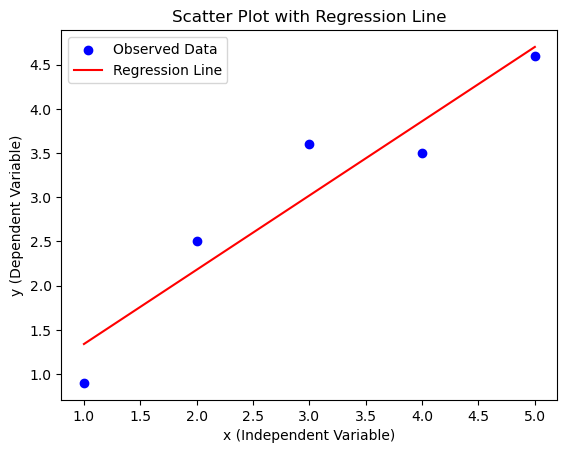

In [34]:
plt.scatter(x, y, color='blue', label='Observed Data')
plt.plot(x, y_pred, color='red', label='Regression Line')
plt.xlabel('x (Independent Variable)')
plt.ylabel('y (Dependent Variable)')
plt.title('Scatter Plot with Regression Line')
plt.legend()
plt.show()

## Task-2

In [64]:
cars_data = pd. read_csv ("used_cars_dataset.csv")

cars_data.head()

data_cleaned = data.dropna()
print(f"Shape after removing missing values: {data_cleaned.shape}")

Shape after removing missing values: (4009, 3169)


In [65]:
categorical_columns = ['brand', 'model', 'fuel_type', 'engine', 'transmission', 'accident']  

data_encoded = pd. get_dummies ( cars_data , dtype=int , columns = categorical_columns , drop_first =True ) 
 
data_encoded.head()

data_encoded.to_csv ('used_cars_encoded.csv', index = False )

X = data_encoded.drop("price", axis=1)
y = data_encoded["price"]

In [67]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,accident,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,At least 1 accident or damage reported,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,At least 1 accident or damage reported,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,None reported,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,None reported,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,None reported,"$34,999"


C:\Users\ramam\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


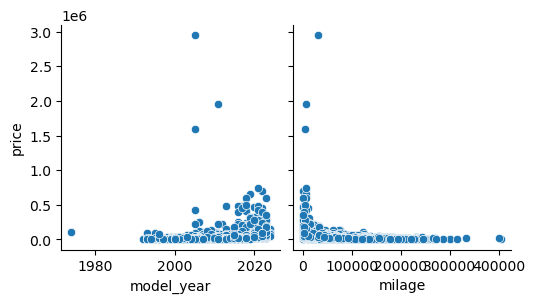

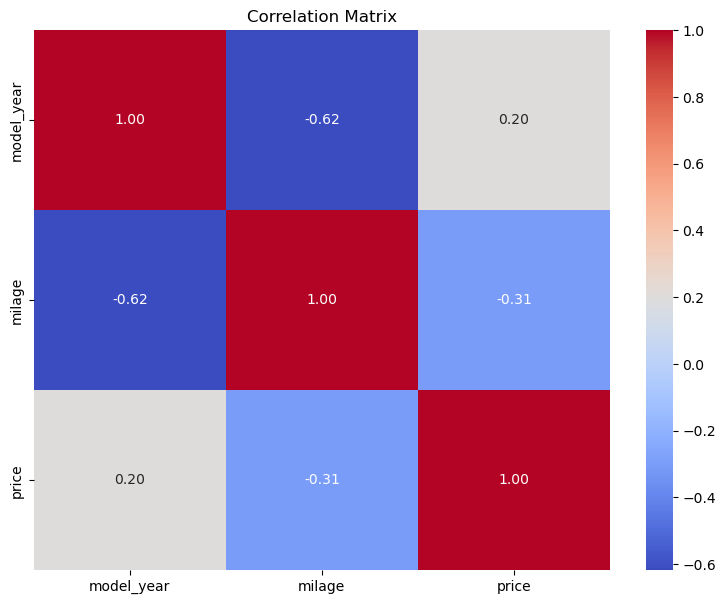

In [78]:
if 'price' in data_encoded.columns:
    data_encoded['price'] = data_encoded['price'].astype(str)
    data_encoded['price'] = (
        data_encoded['price']
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .astype(float)
    )

if 'milage' in data_encoded.columns:
    data_encoded['milage'] = data_encoded['milage'].astype(str)
    data_encoded['milage'] = (
        data_encoded['milage']
        .str.replace(',', '', regex=False)
        .str.replace(' mi.', '', regex=False)
        .astype(float)
    )

data_cleaned = data_encoded[['model_year', 'milage', 'price']].dropna()

sns.pairplot(data_cleaned, y_vars=["price"], x_vars=["model_year", "milage"], height=2.5)
plt.subplots_adjust(top=0.95, bottom=0.05, left=0.05, right=0.95)
plt.show()

correlation_matrix = data_cleaned[['model_year', 'milage', 'price']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.subplots_adjust(top=0.95, bottom=0.05, left=0.05, right=0.95)
plt.show()

In [106]:
data_encoded['price'] = data_encoded['price'].replace({'\$': '', ',': ''}, regex=True)
data_encoded['price'] = pd.to_numeric(data_encoded['price'], errors='coerce')

brand_model_avg_price = data_encoded.groupby(['brand', 'model'])['price'].mean().reset_index()

sorted_dict = (
    brand_model_avg_price
    .sort_values(['brand', 'price'], ascending=[True, False])
    .groupby('brand')
    .apply(lambda x: list(x[['model', 'price']].to_dict('records')))
    .to_dict()
)

model_rank_mapping = {}
for brand, models in sorted_dict.items():
    for rank, model_info in enumerate(models, start=1):
        model_rank_mapping[(brand, model_info['model'])] = rank

data_encoded['model_rank'] = data_encoded.apply(
    lambda x: model_rank_mapping.get((x['brand'], x['model']), None), axis=1
)

def parse_engine(engine_str):
    hp_match = re.search(r'(\d+\.?\d*) HP', engine_str)
    disp_match = re.search(r'(\d+\.?\d*)L', engine_str)
    engine_type_match = re.search(r'(V\d+|I\d+| Electric Motor)', engine_str)
    return {
        'horsepower': float(hp_match.group(1)) if hp_match else None,
        'displacement': float(disp_match.group(1)) if disp_match else None,
        'engine_type': engine_type_match.group(1) if engine_type_match else 'Unknown',
        'is_ev': 1 if 'Electric' in engine_str else 0
    }

engine_features = data_encoded['engine'].apply(parse_engine)
engine_df = pd.DataFrame(engine_features.tolist())
data_encoded = pd.concat([data_encoded, engine_df], axis=1)

def parse_transmission(transmission_str):
    gear_match = re.search(r'(\d+)-Speed', transmission_str)
    transmission_type = 'EV Transmission' if 'EV' in transmission_str else (
        'Automatic' if 'A/T' in transmission_str or 'Automatic' in transmission_str else 'Manual'
    )
    return {
        'transmission_type': transmission_type,
        'num_gears': int(gear_match.group(1)) if gear_match else None
    }

transmission_features = data_encoded['transmission'].apply(parse_transmission)
transmission_df = pd.DataFrame(transmission_features.tolist())
data_encoded = pd.concat([data_encoded, transmission_df], axis=1)

X = data_encoded[['milage', 'model_year', 'model_rank', 'horsepower', 'displacement', 
                  'engine_type', 'is_ev', 'transmission_type', 'num_gears']]
y = data_encoded['price']

X = pd.get_dummies(X, columns=['engine_type', 'transmission_type'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R-squared:", r2)
print("Mean Squared Error:", mse)

KeyError: 'brand'

In [102]:
data_encoded['milage'] = data_encoded['milage'].replace({'mi.': '', ',': ''}, regex=True)
data_encoded['milage'] = pd.to_numeric(data_encoded['milage'], errors='coerce')

data_encoded['price'] = data_encoded['price'].replace({'\$': '', ',': ''}, regex=True)
data_encoded['price'] = pd.to_numeric(data_encoded['price'], errors='coerce')

data_encoded.dropna(subset=['milage', 'price'], inplace=True)

X = data_encoded[['milage', 'model_year']]
y = data_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model Coefficients:", model.coef_)
print("Model Intercept:", model.intercept_)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R-squared:", r2)
print("Mean Squared Error:", mse)

Model Coefficients: [-3.53254925e-01  1.10402684e+03]
Model Intercept: -2159163.038605758
R-squared: 0.028823215810687586
Mean Squared Error: 19850436879.800606


In [105]:
y_pred = model.predict(X_test)

r_squared = r2_score(y_test, y_pred)
n = len(y_test)
p = X.shape[1]
adjusted_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)

print(f"R-squared: {r_squared}")
print(f"Adjusted R-squared: {adjusted_r_squared}")

R-squared: 0.028823215810687586
Adjusted R-squared: 0.02639223512435629


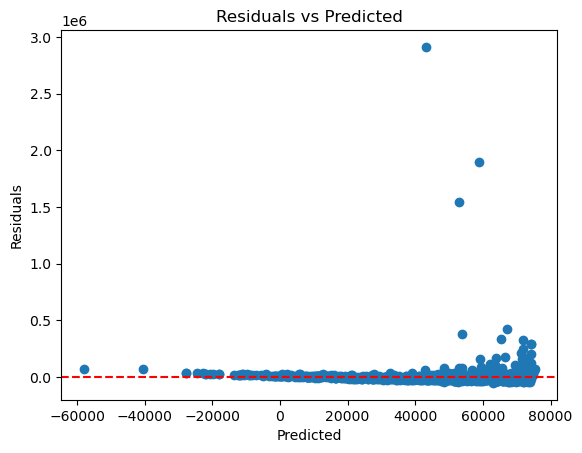

Durbin-Watson statistic: 2.0139407747154072


In [103]:
# Residuals
residuals = y_test - y_pred

# Linearity Test
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Predicted")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

# Durbin-Watson test for independence
dw_stat = durbin_watson(residuals)
print(f"Durbin-Watson statistic: {dw_stat}")

In [104]:
correlated_features = correlation_matrix[abs(correlation_matrix["price"]) > 0.8].index
print(f"Highly correlated features with price: {correlated_features}")

Highly correlated features with price: Index(['price'], dtype='object')
